In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)

In [3]:
iris = load_iris()

x = iris.data
y = iris.target

print("Data Shape : ", x.shape)
print("Target Classes : ", iris.target_names)

Data Shape :  (150, 4)
Target Classes :  ['setosa' 'versicolor' 'virginica']


In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

#Add target column
df['Species'] = iris.target
print(df.head(10))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  
5        0  
6        0  
7        0  
8        0  


In [6]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
print("Missing Values : ", np.isnan(x).sum())

Missing Values :  0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 88, stratify = y)

print("Training Data : ", X_train.shape)
print("Testing Data : ", X_test.shape)

Training Data :  (120, 4)
Testing Data :  (30, 4)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature Scaling Completed")

Feature Scaling Completed


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)

#train
knn.fit(X_train_scaled, y_train)

#predict
y_pred_knn = knn.predict(X_test)

print("KNN Predictions : ")
print(y_pred_knn)

KNN Predictions : 
[1 1 2 2 1 1 1 2 1 0 1 2 2 2 2 0 1 0 0 0 2 0 2 0 0 1 1 0 1 0]


In [11]:
dt = DecisionTreeClassifier(random_state=88)

dt.fit(X_train, y_train)

#predict
y_pred_dt = dt.predict(X_test)
print("Decision Tree Predictions")
print(y_pred_dt)

Decision Tree Predictions
[0 0 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [12]:
print("KNN Accuracy : ", accuracy_score(y_test, y_pred_knn))
print("KNN Precision : ", precision_score(
    y_test, y_pred_knn, average="macro"
))

print("KNN Recall : ", recall_score(
    y_test, y_pred_knn, average="macro"
))

print("KNN F1 Score : ", f1_score(
    y_test, y_pred_knn, average="macro"
))

KNN Accuracy :  0.9666666666666667
KNN Precision :  0.9696969696969697
KNN Recall :  0.9666666666666667
KNN F1 Score :  0.9665831244778613


In [13]:
print("Decision Tree Accuracy : ", accuracy_score(y_test, y_pred_knn))
print("Decision Tree Precision : ", precision_score(
    y_test, y_pred_dt, average="macro"
))

print("Decision Tree Recall : ", recall_score(
    y_test, y_pred_dt, average="macro"
))

print("Decision Tree F1 Score : ", f1_score(
    y_test, y_pred_dt, average="macro"
))

Decision Tree Accuracy :  0.9666666666666667
Decision Tree Precision :  0.15873015873015872
Decision Tree Recall :  0.3333333333333333
Decision Tree F1 Score :  0.21505376344086022


/home/cns/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


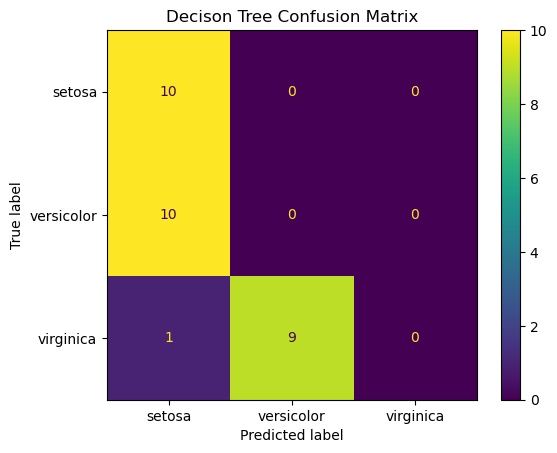

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_dt)

display = ConfusionMatrixDisplay(
    confusion_matrix = cm, 
    display_labels = iris.target_names
)

display.plot()
plt.title("Decison Tree Confusion Matrix")
plt.show()

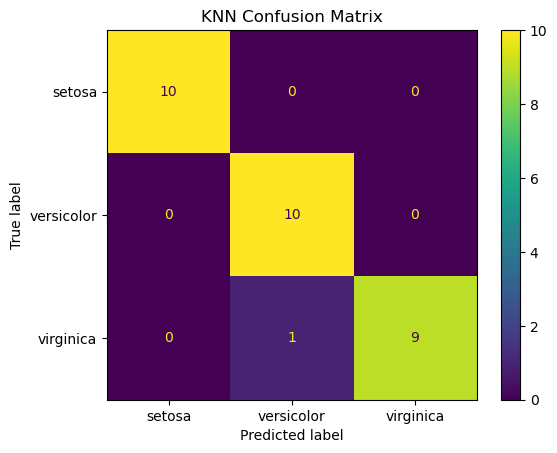

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_knn)

display = ConfusionMatrixDisplay(
    confusion_matrix = cm, 
    display_labels = iris.target_names
)

display.plot()
plt.title("KNN Confusion Matrix")
plt.show()

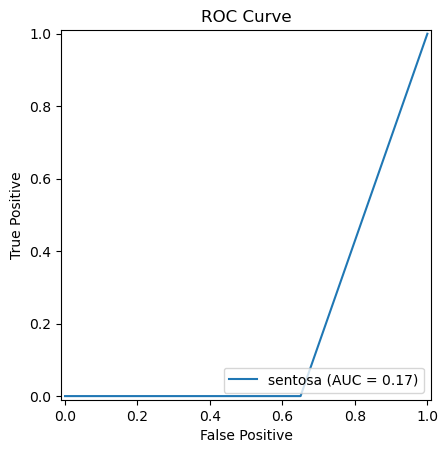

In [16]:
# Plot ROC Curve
from sklearn.metrics import RocCurveDisplay
y_prob_knn = knn.predict_proba(X_test)

#Plot ROC Curve
RocCurveDisplay.from_predictions(
    (y_test == 0).astype(int), y_prob_knn[:,1], name="sentosa"
)
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC Curve")
plt.show()

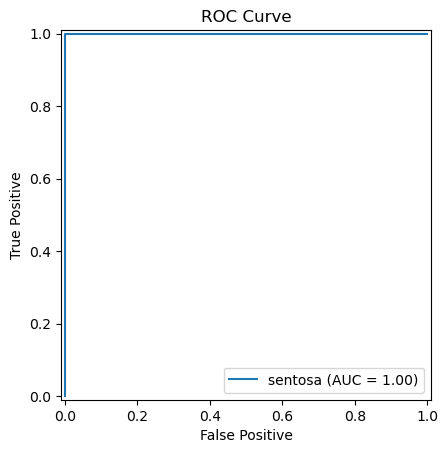

In [17]:
# Plot ROC Curve
from sklearn.metrics import RocCurveDisplay
y_prob_knn = knn.predict_proba(X_test)

#Plot ROC Curve
RocCurveDisplay.from_predictions(
    (y_test == 0).astype(int), y_prob_knn[:,0], name="sentosa"
)
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC Curve")
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt.predict_proba(X_test)
print(y_prob_dt)
auc_dt = roc_auc_score(
    y_test,
    y_prob_dt,
    multi_class='ovr',
    average="macro"
)

print("Decision Tree Axccuracy Score : ", auc_dt)

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
Decision Tree Axccuracy Score :  0.5


In [19]:
# Comapre Both Models
print("KNN Accuracy : ", accuracy_score(y_test, y_pred_knn))
print("Decision Tree Accuracy : ", accuracy_score(y_test, y_pred_dt))
print("KNN Precision : ", precision_score(
    y_test, y_pred_knn, average="macro"
))


print("KNN AUC : ", knn)
print("Decision Tree AUC : ", auc_dt)

print("KNN F1 Score : ", f1_score(
    y_test, y_pred_knn, average="macro"
))
print("Decision Tree F1 Score : ", f1_score(
    y_test, y_pred_dt, average="macro"
))

KNN Accuracy :  0.9666666666666667
Decision Tree Accuracy :  0.3333333333333333
KNN Precision :  0.9696969696969697
KNN AUC :  KNeighborsClassifier()
Decision Tree AUC :  0.5
KNN F1 Score :  0.9665831244778613
Decision Tree F1 Score :  0.21505376344086022
